In [ ]:
# Task: Show Neural Network Architecture by showing simple automatic differentiation (autograd) examples of the forward pass and backward pass. 
# brew install graphviz
# pip install graphviz

In [8]:
from micrograd.engine import Value
from graphviz import Digraph

In [43]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [44]:
# a very simple example
x = Value(1.0)
y = (x * 2 + 1).relu() # y = 2x +1 
y.backward()
draw_dot(y)

AttributeError: 'int' object has no attribute 'data'

In [ ]:
#### Example - we use value class object that stores the data and gradient and 
# stores scalar objects because we are building massive functions. 
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):   # wrapper function is allowing us to print the value object in a nice way.
    return f"Value(data={self.data})" # it returns a string representation of the Value object, showing its data attribute.
  
  def __add__(self, other): # we have to tell the class how to add two value objects together. 
    out = Value(self.data + other.data, (self, other), '+') # we create a new value object that stores the sum of the two values and also stores the two values as children.
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

# L(a, b, c, f) = ((a * b) + c) * f
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = Value(2.0, label='a') * Value(-3.0, label='b'); e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [46]:
from graphviz import Digraph

def trace(root): # we want to trace the graph of operations that led to the final output value.
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set() # we use sets to store nodes and edges to avoid duplicates
  def build(v): # we define a recursive function build that takes a value object v as input.
    if v not in nodes: # we check if the value object v is already in the nodes set. 
        # If it is not, we add it to the nodes set and then iterate over its children 
        # (the values that were used to compute v) and add edges from each child to v. 
        # We then recursively call build on each child to continue tracing the graph.
      nodes.add(v) # we add the value object v to the nodes set to mark it as visited.
      for child in v._prev: # we iterate over the children of the value object v, which are stored in the _prev attribute.
        edges.add((child, v)) # we add an edge from each child to v in the edges set to represent the computation that led to v.
        build(child) # we recursively call build on each child to continue tracing the graph.
  build(root) # we call the build function on the root value object to start tracing the graph from the final output value.
  return nodes, edges # we return the sets of nodes and edges that represent the computation graph.

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

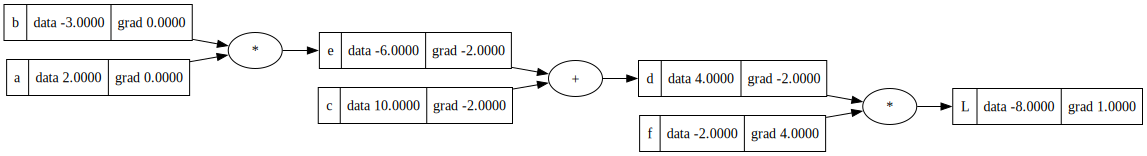

In [49]:
draw_dot(L)
# gradient at L should be 1.0, and the gradients at a, b, c, d, e, f should be computed by backpropagation.

In [ ]:
# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')
# e = a*b; e.label = 'e'
# d = e + c; d.label = 'd'
# f = Value(-2.0, label='f')
# L = d * f; L.label = 'L'
# L
# Backpropagation calculates how much the final output
# Goal is to compuate the gradients of a, b, c, d, e, f with respect to L using backpropagation.

# dL/da, 
# dL/db
# dL/dc
# dL/df

# L(a, b, c, f) = ((a * b) + c) * f
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
e.grad = -2.0
c.grad = -2.0
b.grad = 4.0
a.grad = 6.0


In [54]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  # b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0 + h, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data 
  
  print((L2 - L1)/h) # rise over run, which is the slope of the function at that point. This is the numerical approximation of the gradient.
  
lol()

3.9999999999995595
